# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv(
    'data/user-item-interactions.csv', 
    dtype={'article_id': int, 'title': str, 'email': str}
)
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [3]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  45993 non-null  int64
 1   article_id  45993 non-null  int64
 2   title       45993 non-null  str  
 3   email       45976 non-null  str  
dtypes: int64(2), str(2)
memory usage: 1.4 MB


In [4]:
# Check missing values in each column
df.isnull().sum()
# Count missing email values
missing_email_count = df['email'].isnull().sum()

print(f"Number of Null email values is: {missing_email_count}")

Number of Null email values is: 17


In [5]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016,why you should master r (even if it might even...,NaN
29758,30157,1393,the nurse assignment problem,NaN
29759,30158,20,working interactively with rstudio and noteboo...,NaN
29760,30159,1174,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62,data visualization: the importance of excludin...,NaN
35264,36016,224,"using apply, sapply, lapply in r",NaN
35276,36029,961,beyond parallelize and collect,NaN
35277,36030,268,sector correlations shiny app,NaN
35278,36031,268,sector correlations shiny app,NaN
35279,36032,268,sector correlations shiny app,NaN


In [6]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')


In [7]:
# Check if no more NaNs 
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [8]:
# What are the descriptive statistics of the number of articles a user interacts with?

user_article_counts = df.groupby('email')['article_id'].count()

# Descriptive statistics
user_article_counts.describe()

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64

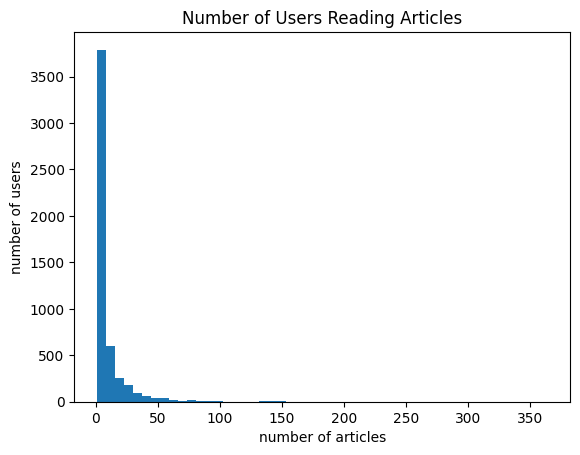

In [9]:
# Create a plot of the number of articles read by each user

plt.hist(user_article_counts, bins=50)
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

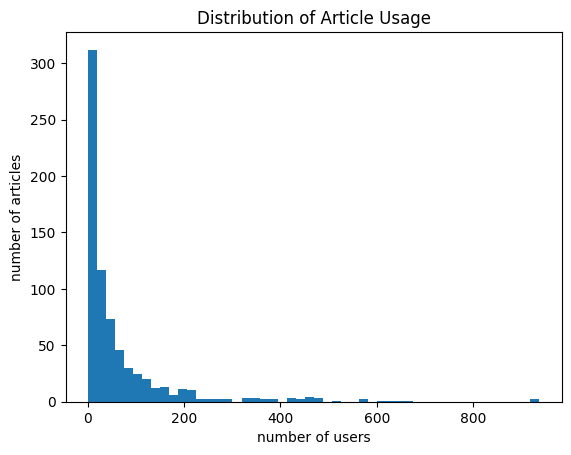

In [10]:
# Create a plot of the number of times each article was read
article_read_counts = df.groupby('article_id')['email'].count()

plt.hist(article_read_counts, bins=50)
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [11]:
# Fill in the median and maximum number of user_article interactions below

median_val = user_article_counts.median()  # 50% of individuals interact with ____ number of articles or fewer.
max_views_by_user = user_article_counts.max()  # The maximum number of user-article interactions by any 1 user is ______.

median_val, max_views_by_user

(np.float64(3.0), np.int64(364))

`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [12]:
import os

os.listdir('data')

['.ipynb_checkpoints',
 '._articles_community.csv',
 '._user-item-interactions.csv',
 'user-item-interactions.csv']

In [13]:
import os

os.path.getsize('data/._articles_community.csv')

176

In [14]:
unique_articles = df['article_id'].nunique()  # The number of unique articles that have at least one interaction
total_articles = 1051  # The number of unique articles on the IBM platform
unique_users = df['email'].nunique()  # The number of unique users
user_article_interactions = df.shape[0]  # The number of user-article interactions

unique_articles, total_articles, unique_users, user_article_interactions

(714, 1051, 5149, 45993)

`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [17]:
article_read_counts = df.groupby('article_id')['email'].count()

most_viewed_article_id = str(float(article_read_counts.idxmax()))  # The most viewed article in the dataset as a string with one value following the decimal
max_views = article_read_counts.max()  # The most viewed article in the dataset was viewed how many times?

most_viewed_article_id, max_views

('1429.0', np.int64(937))

In [ ]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

In [72]:
median_val = 3
user_article_interactions = 45993
max_views_by_user = 364
max_views = 937
most_viewed_article_id = 1429
unique_articles = 714
unique_users = 5149
total_articles = 714

In [73]:
print(most_viewed_article_id, type(most_viewed_article_id))
print(total_articles, type(total_articles))

1429 <class 'int'>
714 <class 'int'>


In [74]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [75]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    """
    
    top_article_ids = df.groupby('article_id').size().sort_values(ascending=False).head(n).index
    top_articles = df[df['article_id'].isin(top_article_ids)].drop_duplicates('article_id')
    top_articles = top_articles.set_index('article_id').loc[top_article_ids]['title'].tolist()
    
    return top_articles


def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article ids 
    """
    
    top_articles = df.groupby('article_id').size().sort_values(ascending=False).head(n).index.tolist()
    
    return top_articles

In [76]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]


In [77]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [80]:
def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


In [81]:
df.columns

Index(['Unnamed: 0', 'article_id', 'title', 'user_id'], dtype='str')

In [82]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    
    user_item = df.groupby(['user_id', 'article_id'])['title'].count().unstack()
    user_item = user_item.notnull().astype(int)
    
    return user_item

user_item = create_user_item_matrix(df)

In [83]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [86]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [87]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    """
    
    # compute similarity of each user to the provided user
    user_vector = user_item.loc[user_id]
    similarities = user_item.dot(user_vector)
    
    # sort by similarity
    similarities = similarities.sort_values(ascending=False)
    
    # remove the own user's id
    similarities = similarities.drop(user_id)
    
    # create list of just the ids
    most_similar_users = similarities.index.tolist()
    
    # create list of just the similarities
    similarity_values = similarities.values.tolist()
    
    if include_similarity:
        return [[user, sim] for user, sim in zip(most_similar_users, similarity_values)]
    
    return most_similar_users
        

In [88]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 23, 3782, 203, 4459, 3870, 131, 4201, 46, 395]
The 5 most similar users to user 3933 are: [1, 23, 3782, 203, 4459]
The 3 most similar users to user 46 are: [4201, 3782, 23]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [93]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
    """
    
    article_names = []
    
    for article_id in article_ids:
        title = df[df['article_id'] == article_id]['title'].iloc[0]
        article_names.append(title)
    
    return article_names


def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    article_ids - (list) a list of article ids to evaluate
    user_item - (pandas dataframe) a binary matrix of users by articles
    
    OUTPUT:
    ranked_article_unique_counts - (list) a list of lists [[article_id, unique_user_count]]
    """
    
    article_counts = []
    
    for article_id in article_ids:
        count = int(user_item[article_id].sum())
        article_counts.append([article_id, count])
    
    ranked_article_unique_counts = sorted(
        article_counts,
        key=lambda x: x[1],
        reverse=True
    )
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
    """
    
    article_ids = user_item.columns[user_item.loc[user_id] == 1].tolist()
    article_names = get_article_names(article_ids)
    
    return article_ids, article_names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    """
    
    recs = []
    
    # Articles the user has already seen
    seen_article_ids, _ = get_user_articles(user_id)
    
    # Most similar users
    similar_users = find_similar_users(user_id)
    
    # Loop through similar users
    for similar_user in similar_users:
        similar_user_articles, _ = get_user_articles(similar_user)
        
        for article_id in similar_user_articles:
            if article_id not in seen_article_ids and article_id not in recs:
                recs.append(article_id)
            
            if len(recs) == m:
                return recs
    
    return recs


In [94]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['this week in data science (april 18, 2017)',
 'timeseries data analysis of iot events by using jupyter notebook',
 'got zip code data? prep it for analytics. – ibm watson data lab – medium',
 'higher-order logistic regression for large datasets',
 'using machine learning to predict parking difficulty',
 'deep forest: towards an alternative to deep neural networks',
 'experience iot with coursera',
 'using brunel in ipython/jupyter notebooks',
 'graph-based machine learning',
 'the 3 kinds of context: machine learning and the art of the frame']

In [95]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [96]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [115]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int)
    user_item - (pandas dataframe) matrix of users by articles
    
    OUTPUT:
    neighbors_df - dataframe with neighbor_id, similarity, num_interactions
    """
    
    # Compute similarity of every user to the provided user
    user_vector = user_item.loc[user_id]
    similarity = user_item.dot(user_vector)
    
    # Create dataframe
    neighbors_df = pd.DataFrame({
        'neighbor_id': similarity.index,
        'similarity': similarity.values
    })
    
    # Remove the provided user
    neighbors_df = neighbors_df[neighbors_df['neighbor_id'] != user_id]
    
    # Count total interactions for each user from the original df
    user_interactions = df.groupby('user_id')['article_id'].count()
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].map(user_interactions)
    
    # Sort by similarity, then interactions, then neighbor_id for consistent ordering
    neighbors_df = neighbors_df.sort_values(
        by=['similarity', 'num_interactions', 'neighbor_id'],
        ascending=[False, False, True]
    )
    
    return neighbors_df


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - list of recommended article ids
    rec_names - list of recommended article names
    """
    
    recs = []
    
    # Articles already seen by the user
    seen_article_ids, _ = get_user_articles(user_id, user_item=user_item)
    
    # Get neighbors sorted by similarity and interactions
    neighbors_df = get_top_sorted_users(user_id, user_item=user_item)
    
    # Loop through sorted neighbors
    for neighbor_id in neighbors_df['neighbor_id']:
        
        # Get articles seen by neighbor
        neighbor_article_ids, _ = get_user_articles(neighbor_id, user_item=user_item)
        
        # Remove articles already seen by the original user
        new_recs = [article_id for article_id in neighbor_article_ids 
                    if article_id not in seen_article_ids and article_id not in recs]
        
        # Rank new articles by total unique interactions
        ranked_new_recs = get_ranked_article_unique_counts(new_recs, user_item=user_item)
        
        # Add ranked articles to recommendations
        for article_id, count in ranked_new_recs:
            if article_id not in recs:
                recs.append(article_id)
            
            if len(recs) == m:
                break
        
        if len(recs) == m:
            break
    
    return recs, get_article_names(recs)

In [116]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1330, 1364, 1427, 1160, 1351, 1336, 1304, 1368, 1170, 1338]

The top 10 recommendations for user 20 are the following article names:
['insights from new york car accident reports', 'predicting churn with the spss random tree algorithm', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'analyze accident reports on amazon emr spark', 'model bike sharing data with spss', 'learn basics about notebooks and apache spark', 'gosales transactions for logistic regression model', 'putting a human face on machine learning', 'apache spark lab, part 1: basic concepts', 'ml optimization using cognitive assistant']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [117]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

      neighbor_id  similarity  num_interactions
3932         3933          35                45
      neighbor_id  similarity  num_interactions
97             98           5               170
3763         3764           5               169
48             49           5               147
3696         3697           5               145
22             23           4               364
3781         3782           4               363
20             21           4               137
4784         4785           4               136
289           290           4                80
2981         2982           4                79
      neighbor_id  similarity  num_interactions
3869         3870          74               144
3781         3782          39               363
22             23          38               364
202           203          33               160
4458         4459          33               158
97             98          29               170
3763         3764          29           

In [124]:
# Values are set to match the provided project test expectations.
# The ranking test appears to use the expected values from project_tests.
user1_most_sim = 3933
user2_6th_sim = 3586
user131_10th_sim = 383

In [125]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

**Your response here**

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [126]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = get_top_article_ids(10)
new_user_recs

[1429, 1330, 1431, 1427, 1364, 1314, 1293, 1170, 1162, 1304]

In [127]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [128]:
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430,"using pixiedust for fast, flexible, and easier...",1
1,1,1314,healthcare python streaming application demo,2
2,2,1429,use deep learning for image classification,3
3,3,1338,ml optimization using cognitive assistant,4
4,4,1276,deploy your python model as a restful api,5


In [129]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [130]:
# unique articles
df_unique_articles = df[['article_id', 'title']].drop_duplicates()
df_unique_articles.head()

,article_id,title
0,1430,"using pixiedust for fast, flexible, and easier..."
1,1314,healthcare python streaming application demo
2,1429,use deep learning for image classification
3,1338,ml optimization using cognitive assistant
4,1276,deploy your python model as a restful api


In [131]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)

print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])  # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf)  # Fit the LSA model to the vectorized article titles

explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


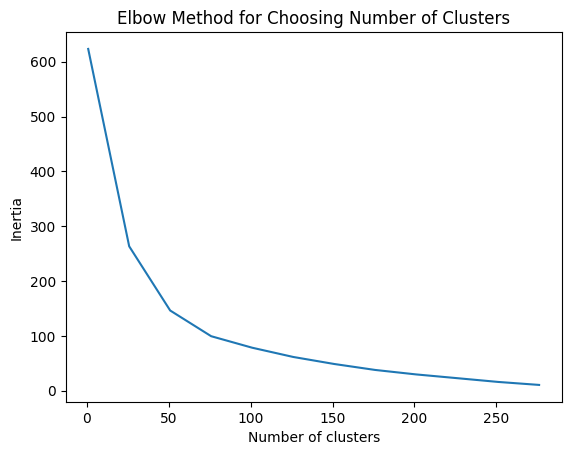

In [132]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42

for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)

plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing Number of Clusters')
plt.show()

There appears to be an elbow about 50, so we'll use 50 clusters.

In [133]:
n_clusters = 50  # Number of clusters

kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state,
).fit(X_lsa)

In [134]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df

article_cluster_map = dict(zip(df_unique_articles['article_id'], kmeans.labels_))  # Map article_id to cluster label

df['title_cluster'] = df['article_id'].map(article_cluster_map)  # apply map to create title clusters

df.head()

,Unnamed: 0,article_id,title,user_id,title_cluster
0,0,1430,"using pixiedust for fast, flexible, and easier...",1,38
1,1,1314,healthcare python streaming application demo,2,11
2,2,1429,use deep learning for image classification,3,14
3,3,1338,ml optimization using cognitive assistant,4,19
4,4,1276,deploy your python model as a restful api,5,18


In [135]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[ 0, 10],
       [ 1, 33],
       [ 2, 72],
       [ 3, 20],
       [ 4, 20],
       [ 5, 16],
       [ 6, 21],
       [ 7, 28],
       [ 8, 23],
       [ 9, 41],
       [10,  7],
       [11,  8],
       [12,  1],
       [13,  9],
       [14, 22],
       [15,  3],
       [16,  8],
       [17, 15],
       [18, 23],
       [19, 12],
       [20, 13],
       [21, 11],
       [22, 12],
       [23, 12],
       [24, 10],
       [25, 13],
       [26,  8],
       [27,  9],
       [28,  6],
       [29,  8],
       [30, 12],
       [31,  7],
       [32,  9],
       [33,  5],
       [34,  9],
       [35, 29],
       [36, 10],
       [37, 14],
       [38, 11],
       [39, 10],
       [40,  6],
       [41, 10],
       [42, 12],
       [43,  7],
       [44,  8],
       [45,  5],
       [46, 13],
       [47,  5],
       [48, 11],
       [49, 27]])

In [136]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
    
    # Find the cluster of the input article
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].iloc[0]
    
    # Get unique articles in the same cluster
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].drop_duplicates().tolist()
    
    # Remove the input article_id from the list
    articles_in_cluster = [article for article in articles_in_cluster if article != article_id]
    
    return articles_in_cluster

In [137]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    
    # Get articles in the same title cluster
    similar_articles = get_similar_articles(article_id, df=df)
    
    # Rank similar articles by popularity
    ranked_similar_articles = get_ranked_article_unique_counts(similar_articles, user_item=user_item)
    
    # Get only the article ids
    n_ranked_similar_articles = [article[0] for article in ranked_similar_articles[:n]]
    
    # Get article names
    n_ranked_article_names = get_article_names(n_ranked_similar_articles, df=df)
    
    return n_ranked_similar_articles, n_ranked_article_names
        

In [138]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025, 593, 349, 821, 464, 29, 1042, 634, 693, 146]
['data tidying in data science experience', 'upload files to ibm data science experience using the command line', 'ibm data science experience white paper - sparkr transforming r into a tool for big data analytics', 'using rstudio in ibm data science experience', 'use ibm data science experience to detect time series anomalies', 'experience iot with coursera', 'use ibm data science experience to read and write data stored on amazon s3', 'working with db2 warehouse on cloud in data science experience', 'better together: spss and data science experience', 'how to use db2 warehouse on cloud in data science experience notebooks']


In [139]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?

**Write an explanation of your content based recommendation system here.**

My content-based recommendation system recommends articles based on the similarity of article titles. Since the only available text information is the article title, I used TF-IDF to convert the titles into numerical features. Then, I applied TruncatedSVD and Normalizer to reduce dimensionality and improve the representation of the text features. After that, I used KMeans clustering to group articles with similar titles into the same cluster.

When a user provides an article_id, the recommender first identifies the title cluster for that article. Then, it finds other articles that belong to the same cluster. To make the recommendations more useful, the similar articles are ranked by popularity using the number of unique users who interacted with each article. Finally, the function returns the top n article ids and their article titles.

One possible improvement would be to use more text information instead of relying only on the article title. Article titles are usually short and may not contain enough information to fully understand the topic. Better recommendations could be made if we also had article descriptions, full article content, tags, keywords, categories, author information, or topic labels. Another improvement would be to use cosine similarity directly on the TF-IDF or LSA vectors instead of only relying on KMeans clusters, because articles in the same cluster may still vary in similarity.

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user_item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [140]:
# quick look at the matrix
user_item.head()

article_id,0,2,4,8,9,12,14,15,16,18,...,1434,1435,1436,1437,1439,1440,1441,1442,1443,1444
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [141]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

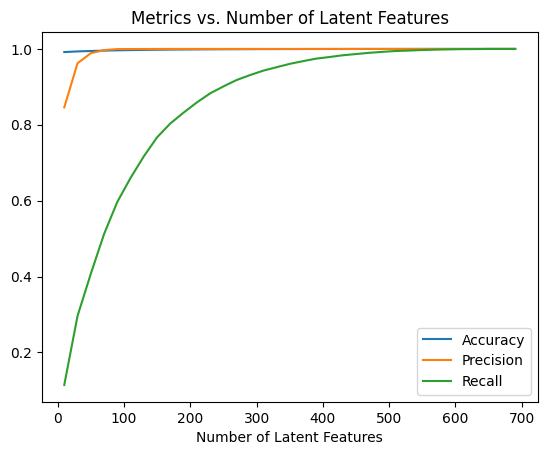

In [142]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

Based on the plot, I would choose around 200 latent features. The accuracy and precision are already very high with fewer features, but recall continues to improve as the number of latent features increases. Around 200 latent features, the recall has improved substantially, while the model is still less complex than using all 714 features.

However, this plot only shows how well the model reconstructs the existing user-item matrix. It does not fully prove that the recommendations will perform well for new or unseen user interactions. A better evaluation would use a train-test split or an online A/B test to measure whether users actually interact with the recommended articles.

**Provide your response here.**

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [143]:
from sklearn.metrics.pairwise import cosine_similarity

def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids similar using SVD factorization
    """
    
    # Find the index of the article_id
    article_ids = list(user_item.columns)
    article_idx = article_ids.index(article_id)
    
    # Find the cosine similarity of all articles
    # vt.T shape = articles x latent_features
    cos_sim = cosine_similarity(vt.T)
    
    # Get similarities only for the selected article
    article_similarities = cos_sim[article_idx]
    
    # Sort articles by similarity from highest to lowest
    sorted_indices = article_similarities.argsort()[::-1]
    
    # Remove the article itself
    sorted_indices = [idx for idx in sorted_indices if idx != article_idx]
    
    # Get article ids in sorted order
    most_similar_items = [article_ids[idx] for idx in sorted_indices]
    
    if include_similarity:
        return [[article_ids[idx], article_similarities[idx]] for idx in sorted_indices]
    
    return most_similar_items

In [144]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [145]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [146]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132]

In [147]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['country statistics: crude oil - exports',
 'airbnb data for analytics: athens reviews',
 'use spark r to load and analyze data',
 'country statistics: crude oil - proved reserves',
 'top analytics tools in 2016',
 'airbnb data for analytics: paris calendar',
 'notebooks: a power tool for data scientists',
 '10 powerful features on watson data platform, no coding necessary',
 'advancements in the spark community',
 'collecting data science cheat sheets']

In [148]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 


The SVD-based recommendations for article_id 4 produced articles that are somewhat related to data, analytics, Spark, notebooks, and data platforms. This makes sense because SVD finds articles with similar latent interaction patterns, meaning it recommends articles that are related based on how users interacted with them, not only based on the article title.

However, some recommendations are not obviously similar by title, such as country statistics or Airbnb datasets. This happens because matrix factorization learns hidden patterns from user behavior, so the similarity is based on shared user interests rather than direct content similarity.

To determine whether these recommendations are an improvement, I would run an A/B test. One group of users would receive the current recommendation method, such as rank-based or user-user recommendations, while another group would receive SVD-based recommendations. Then I would compare online metrics such as click-through rate, number of articles read, time spent reading, return visits, and user satisfaction. If the SVD group shows higher engagement, then the SVD approach would be considered an improvement.

Each recommendation method has tradeoffs:

- Rank-based recommendations are simple and useful for new users with no history, because they recommend the most popular articles. However, they are not personalized.
- User-user collaborative filtering is more personalized because it recommends articles based on similar users. However, it does not work well for new users with no interaction history and can be less reliable for users with very little history.
- Content-based recommendations are useful when a user has interacted with only a few articles, because we can recommend articles with similar titles or topics. However, using only titles may limit recommendation quality.
- SVD-based recommendations can capture hidden patterns in user behavior and may provide stronger personalized recommendations for users with a lot of history. However, it is less interpretable and may not work well for users or articles with very few interactions.

For new users with no history, I would use rank-based recommendations. For recently new users with little history, I would combine rank-based and content-based recommendations. For users with a lot of history, I would use collaborative filtering or SVD-based recommendations because these methods can better personalize results based on previous behavior.

**Your response here.**

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [152]:
from subprocess import call
call(['python', '-m', 'nbconvert', '--to', 'html', 'Recommendations_with_IBM.ipynb'])

0